**Bitcoin Sentiment Analysis** **bold text**

**Domain - Cryptocurrency Analytics**

**Objective**

1. To analyze the relationship between Bitcoin market sentiment and historical trading performance.

2. To integrate the Historical Trader Dataset with the Bitcoin Fear & Greed Index using a common date field.

3. To clean, preprocess, and prepare the datasets for accurate analysis.

4. To perform Exploratory Data Analysis (EDA) to identify trading patterns and trends.

5. To evaluate trader profitability under different market sentiment conditions.

6. To visualize key insights using charts and statistical summaries for better decision-making.








**Out Come**

1. To visualize key insights using charts and statistical summaries for better decision-making.

2. Cleaned and preprocessed the data to ensure consistency and reliability.

3. Performed Exploratory Data Analysis (EDA) to examine trading behavior and market sentiment.

4. Identified patterns in trader profitability across different market sentiment categories.

5. Created meaningful visualizations to present trading activity, profit distribution, and feature relationships.

6. Generated actionable insights into how market sentiment influences cryptocurrency trading performance.



**Types of Analaysis**

1. Descriptive Analysis - Summarizes trading data using statistical measures such as count, mean, minimum, maximum, and standard deviation.

2. Exploratory Data Analysis (EDA) - Examines data distributions, trading behavior, and relationships using visualizations and summary statistics.

3. Comparative Analysis - Compares trader profitability and trading activity across different market sentiment categories (Fear, Greed, Extreme Fear, etc.).

4. Correlation Analysis - Identifies relationships between numerical variables such as execution price, trade size, fees, and closed profit/loss using a correlation matrix.

5. Trend Analysis - Observes patterns in market sentiment and trading behavior to derive meaningful business insights.

**Import Required Libraries**

**Pandas** - is used for loading and manipulating datasets.

**NumPy** - is used for numerical computations.

**Matplotlib** - is used to create charts and visualizations.

Warnings are ignored to keep the notebook output clean and readable.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

**Load the Datasets**

In [6]:
trader = pd.read_csv("historical_data.csv", low_memory=False)

sentiment = pd.read_csv("fear_greed_index.csv")

**Display the First Five Records**
  
The head() function displays the first five rows of each dataset to understand the available columns and verify successful loading.

In [7]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


**Check Dataset Dimensions**

The shape function returns the number of rows and columns in each dataset.

This helps understand the size of the data before beginning analysis.

In [10]:
print("Historical Trader Dataset Shape:", trader.shape)
print("Fear & Greed Dataset Shape:", sentiment.shape)

Historical Trader Dataset Shape: (23285, 16)
Fear & Greed Dataset Shape: (2644, 4)


**View Column Names**

This step lists all available columns in both datasets.

Understanding column names helps identify which variables will be used during data analysis and merging.

In [11]:
print(trader.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


**Check Data Types**

The info() function displays:

Number of records
Data types
Missing values
Memory usage

This helps understand the overall quality of the datasets.

In [12]:
trader.info()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23285 entries, 0 to 23284
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Account           23285 non-null  object 
 1   Coin              23285 non-null  object 
 2   Execution Price   23285 non-null  float64
 3   Size Tokens       23285 non-null  float64
 4   Size USD          23285 non-null  float64
 5   Side              23285 non-null  object 
 6   Timestamp IST     23285 non-null  object 
 7   Start Position    23285 non-null  float64
 8   Direction         23285 non-null  object 
 9   Closed PnL        23285 non-null  float64
 10  Transaction Hash  23285 non-null  object 
 11  Order ID          23284 non-null  float64
 12  Crossed           23284 non-null  object 
 13  Fee               23284 non-null  float64
 14  Trade ID          23284 non-null  float64
 15  Timestamp         23284 non-null  float64
dtypes: float64(9), object(7)
memory usage: 2

**Check Missing Values**

Missing values can affect analysis.

This step counts the number of null values present in each column.

In [13]:
trader.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [14]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


**Check Duplicate Records**

Duplicate records can produce misleading analysis.

This step checks whether duplicate rows exist in either dataset.

In [15]:
print(trader.duplicated().sum())
print(sentiment.duplicated().sum())

0
0


**Statistics**

The describe() function provides descriptive statistics including:

Mean
Minimum
Maximum
Standard Deviation
Quartiles

This helps understand the numerical distribution of data.

In [16]:
trader.describe(include="all")

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,23285,23285,23285.000000,23285.000000,2.328500e+04,23285,23285,23285.000000,23285,23285.000000,23285,2.328400e+04,23284,23284.000000,2.328400e+04,2.328400e+04
unique,7,68,NaN,NaN,NaN,2,1314,NaN,10,NaN,8781,NaN,2,NaN,NaN,NaN
top,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,12236,9384,NaN,NaN,NaN,11687,441,NaN,6694,NaN,607,NaN,14645,NaN,NaN,NaN
mean,NaN,NaN,36045.923449,567.266084,2.237438e+04,NaN,NaN,5981.109313,NaN,144.845363,NaN,7.368365e+10,NaN,4.094936,5.643518e+14,1.739884e+12
std,NaN,NaN,42700.891030,7954.520330,9.947701e+04,NaN,NaN,57549.411390,NaN,2064.020558,NaN,1.974804e+10,NaN,16.667163,3.249315e+14,9.670037e+09
min,NaN,NaN,0.000010,0.000010,0.000000e+00,NaN,NaN,-1000000.000000,NaN,-117990.104100,NaN,1.340007e+10,NaN,0.000000,0.000000e+00,1.710000e+12
25%,NaN,NaN,26.353000,0.106610,5.241300e+02,NaN,NaN,-47.145000,NaN,0.000000,NaN,6.919673e+10,NaN,0.021735,2.830000e+14,1.740000e+12
50%,NaN,NaN,2922.400000,1.129480,1.998540e+03,NaN,NaN,21.747330,NaN,0.000000,NaN,8.467824e+10,NaN,0.238015,5.630000e+14,1.740000e+12
75%,NaN,NaN,85134.000000,24.000000,1.010160e+04,NaN,NaN,300.000000,NaN,11.193952,NaN,8.766790e+10,NaN,2.299808,8.470000e+14,1.750000e+12


In [17]:
sentiment.describe(include="all")

,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2025-05-02
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


**Date Columns**

The date columns are inspected before converting them into datetime format.

This ensures both datasets use compatible date formats for merging.

In [18]:
trader['Timestamp IST'].head()

,Timestamp IST
0,02-12-2024 22:50
1,02-12-2024 22:50
2,02-12-2024 22:50
3,02-12-2024 22:50
4,02-12-2024 22:50


In [19]:
sentiment['date'].head()

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


**Convert Dates**

The trader timestamp is converted into datetime format.

A new Date column is extracted because the sentiment dataset records one value per day.

Similarly, the sentiment date is converted into datetime format.

In [20]:
trader['Timestamp IST'] = pd.to_datetime(
    trader['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

# Create Date column
trader['Date'] = trader['Timestamp IST'].dt.date


# Convert sentiment date to datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Create Date column
sentiment['Date'] = sentiment['date'].dt.date

The newly created Date column is displayed to verify successful conversion.

In [21]:
trader[['Timestamp IST', 'Date']].head()

,Timestamp IST,Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [22]:
sentiment[['date', 'Date']].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


**Count Unique Dates**

This step compares the number of unique trading dates with the number of sentiment dates.

In [23]:
print("Unique Trader Dates:", trader['Date'].nunique())
print("Unique Sentiment Dates:", sentiment['Date'].nunique())

Unique Trader Dates: 263
Unique Sentiment Dates: 2644


Both datasets are merged using the Date column.

This combines every trade with the corresponding daily market sentiment.

A left join ensures that all trading records are retained.

In [24]:
merged_df = pd.merge(
    trader,
    sentiment[['Date', 'classification', 'value']],
    on='Date',
    how='left'
)

The merged dataset is inspected to ensure the sentiment columns have been added successfully.

In [25]:
merged_df.head()
merged_df.shape

(23285, 19)

Some trading dates may not have matching sentiment data.

This step identifies those missing records.

In [26]:
merged_df[['classification', 'value']].isnull().sum()

,0
classification,6
value,6


In [27]:
merged_df[merged_df['classification'].isnull()][['Timestamp IST','Date']]

,Timestamp IST,Date
727,2024-10-26 04:44:00,2024-10-26
728,2024-10-26 04:52:00,2024-10-26
729,2024-10-26 04:52:00,2024-10-26
730,2024-10-26 04:52:00,2024-10-26
731,2024-10-26 04:52:00,2024-10-26
732,2024-10-26 04:53:00,2024-10-26


This checks whether a specific missing date exists in the sentiment dataset.

In [28]:
sentiment[sentiment['Date'] == '2024-10-26']

,timestamp,value,classification,date,Date


Rows without sentiment information are removed to ensure accurate analysis.

In [29]:
merged_df = merged_df.dropna(subset=['classification'])

The final cleaned dataset is checked before analysis begins.

In [30]:
print(merged_df.shape)

merged_df[['classification','value']].isnull().sum()

(23279, 19)


,0
classification,0
value,0


**Summary Statistics**

Generate descriptive statistics for all numerical variables in the merged dataset.

In [31]:
merged_df.describe()

,Execution Price,Size Tokens,Size USD,Timestamp IST,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp,value
count,23279.000000,23279.000000,2.327900e+04,23279,23279.000000,23279.000000,2.327800e+04,23278.000000,2.327800e+04,2.327800e+04,23279.000000
mean,36055.213351,566.003404,2.237633e+04,2025-02-16 04:00:39.695004160,5986.163622,143.058219,7.369216e+10,4.095625,5.643138e+14,1.739886e+12,50.205851
min,0.000010,0.000010,0.000000e+00,2024-03-13 20:15:00,-1000000.000000,-117990.104100,1.340007e+10,0.000000,0.000000e+00,1.710000e+12,10.000000
25%,26.364500,0.106480,5.241300e+02,2025-02-04 03:48:00,-46.970000,0.000000,6.919673e+10,0.021714,2.830000e+14,1.740000e+12,38.000000
50%,2922.500000,1.129140,1.998520e+03,2025-04-07 19:53:00,21.758400,0.000000,8.473896e+10,0.238014,5.630000e+14,1.740000e+12,48.000000
75%,85134.000000,24.000000,1.010056e+04,2025-04-21 02:17:00,300.154983,11.182028,8.766790e+10,2.299808,8.470000e+14,1.750000e+12,63.000000
max,99245.000000,682429.000000,3.921431e+06,2025-05-01 07:06:00,729046.000000,135329.090100,9.011144e+10,837.471593,1.130000e+15,1.750000e+12,94.000000
std,42702.472242,7954.870906,9.948958e+04,NaN,57555.708127,2059.567101,1.974347e+10,16.669246,3.249103e+14,9.669981e+09,16.384848


**Distribution of Market Sentiment**

Determine how frequently each market sentiment occurs.

Bar chart

In [32]:
merged_df['classification'].value_counts()

,count
classification,
Fear,8947
Greed,6545
Neutral,4763
Extreme Greed,2145
Extreme Fear,879


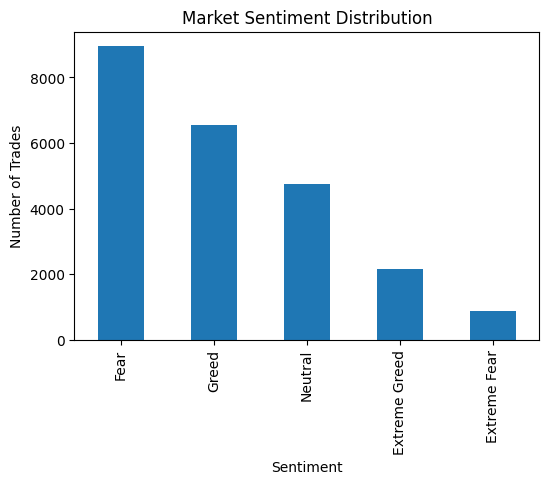

In [33]:
merged_df['classification'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Market Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.show()

**Closed Profit/Loss Distribution**

Visualize how trader profits and losses are distributed.

Histogram

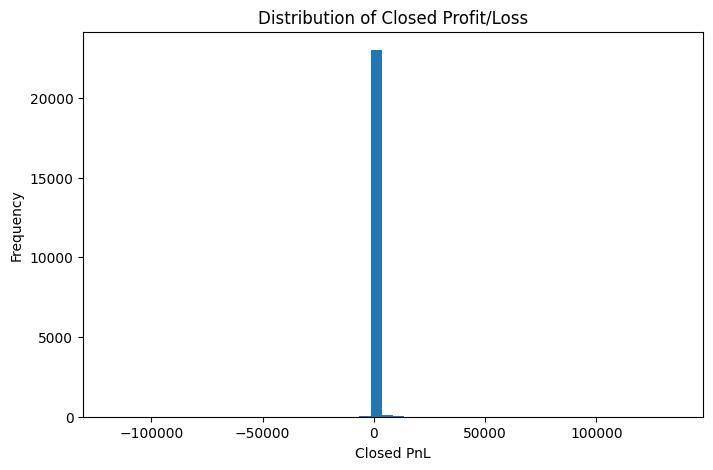

In [34]:
plt.figure(figsize=(8,5))

plt.hist(merged_df['Closed PnL'], bins=50)

plt.title("Distribution of Closed Profit/Loss")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")

plt.show()

**Average Profit by Sentiment**

Shows median, spread, and outliers for each sentiment; much more informative than averages alone

Box Plot

In [35]:
profit_sentiment = merged_df.groupby('classification')['Closed PnL'].mean()

profit_sentiment

,Closed PnL
classification,
Extreme Fear,282.531145
Extreme Greed,62.654241
Fear,173.135987
Greed,120.778213
Neutral,127.644968


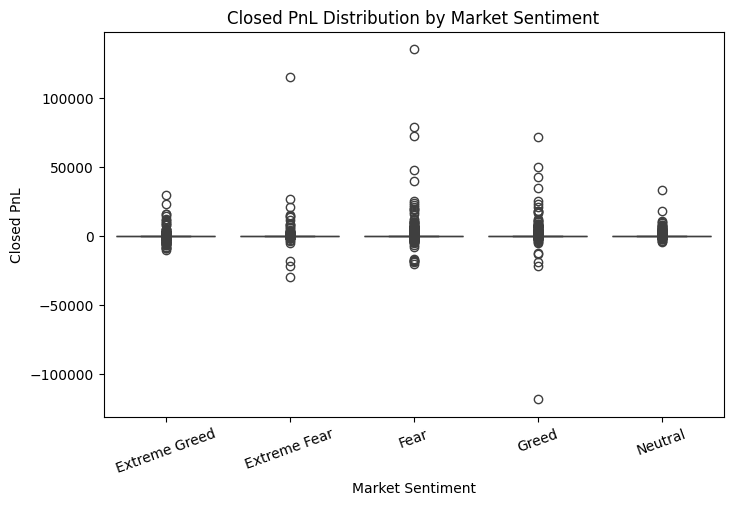

In [36]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged_df
)

plt.title("Closed PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=20)
plt.show()

**Buy vs Sell Trades**

Compare the proportion of Buy and Sell transactions.

Pie Charts

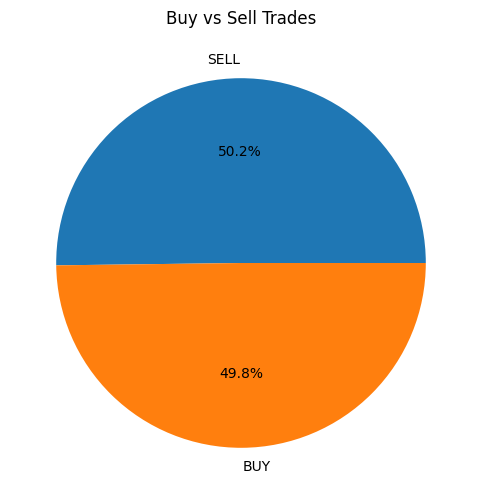

In [37]:
merged_df['Side'].value_counts()
merged_df['Side'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Buy vs Sell Trades")

plt.show()

Measure relationships between numerical variables using Pearson correlation.

Heatmap

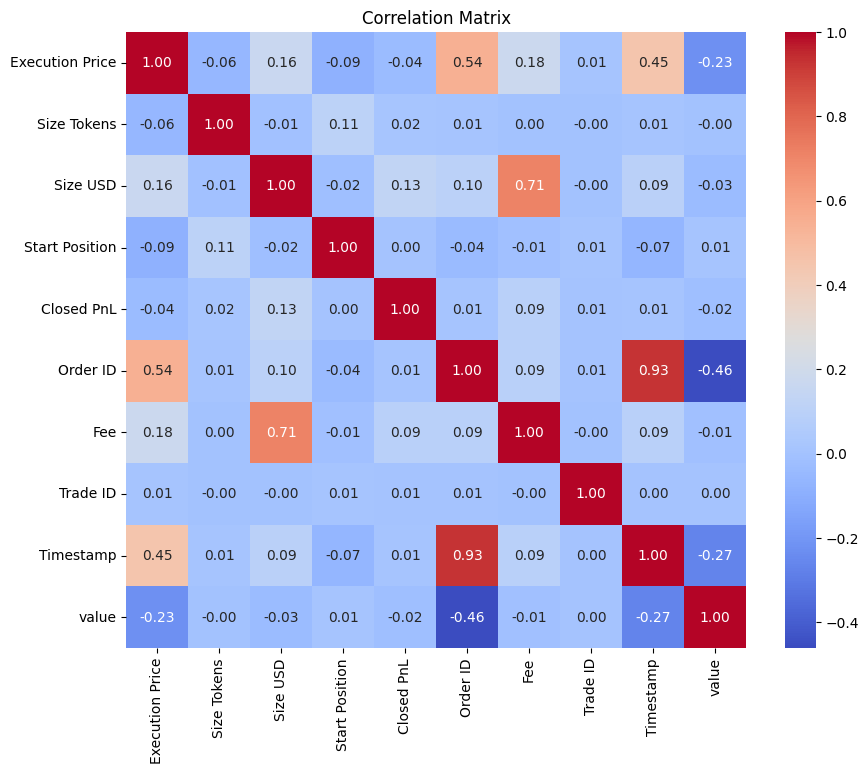

In [40]:


import seaborn as sns

numeric_cols = merged_df.select_dtypes(include='number')

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

**Hidden Pattern Discovery**

**Win Rate & Profit Factor by Market Sentiment**

How does trader performance vary across different market sentiment conditions?

This analysis evaluates trading performance using two important metrics:

- **Win Rate (%)** - Percentage of profitable trades.
- **Profit Factor** - Ratio of total profit to total loss.

These metrics help identify which market sentiment provides the most favorable trading environment.

In [42]:
def trade_statistics(group):

    wins = group[group['Closed PnL'] > 0]['Closed PnL']
    losses = group[group['Closed PnL'] < 0]['Closed PnL']

    total_profit = wins.sum()
    total_loss = abs(losses.sum())

    return pd.Series({
        'Total Trades': int(len(group)),
        'Winning Trades': int((group['Closed PnL'] > 0).sum()),
        'Win Rate (%)': round((group['Closed PnL'] > 0).mean() * 100, 2),
        'Average Profit': round(wins.mean(), 2),
        'Average Loss': round(losses.mean(), 2),
        'Profit Factor': round(total_profit / total_loss, 2) if total_loss != 0 else np.nan
    })

sentiment_stats = merged_df.groupby('classification').apply(trade_statistics)

display(sentiment_stats)

,Total Trades,Winning Trades,Win Rate (%),Average Profit,Average Loss,Profit Factor
classification,,,,,,
Extreme Fear,879.0,251.0,28.56,1432.61,-690.94,3.23
Extreme Greed,2145.0,328.0,15.29,879.39,-819.40,1.87
Fear,8947.0,3615.0,40.40,502.02,-471.23,6.83
Greed,6545.0,2410.0,36.82,425.74,-1090.49,4.36
Neutral,4763.0,2244.0,47.11,287.08,-315.08,17.78


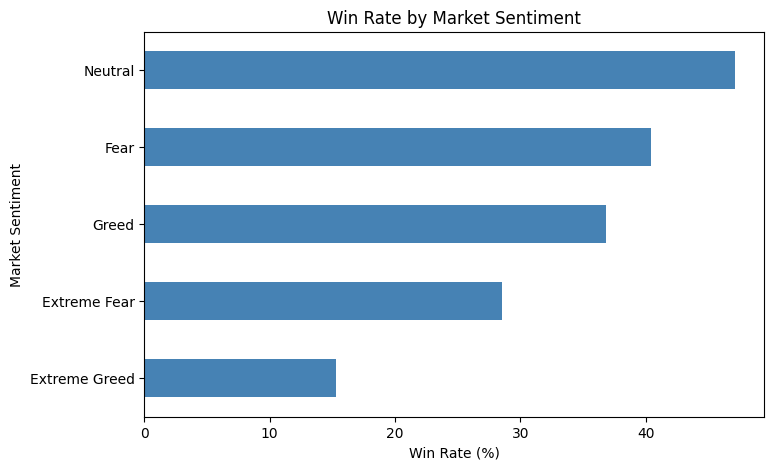

In [43]:
plt.figure(figsize=(8,5))

sentiment_stats['Win Rate (%)'].sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Win Rate (%)")
plt.ylabel("Market Sentiment")

plt.show()

**Interpretation**

**Key Findings**

- Neutral market sentiment achieved the highest Win Rate (47.11%) and Profit Factor (17.78).
- Fear sentiment showed strong trading performance with a Win Rate of 40.40%.
- Greed delivered moderate profitability compared to Fear.
- Extreme Greed recorded the lowest Win Rate (15.29%) and Profit Factor (1.87).

**Business Insight**

- Traders performed best during Neutral and Fear market conditions.
- Extreme Greed was associated with the weakest trading performance.
- Market sentiment can be used as an indicator to improve trading decisions.

**Buy vs Sell Performance by Market Sentiment**

Does the profitability of Buy and Sell trades vary across different market sentiment conditions?

This analysis compares the average Closed Profit/Loss (PnL) of Buy and Sell trades under each market sentiment category to identify which trading side performs better.

In [44]:
buy_sell_performance = merged_df.pivot_table(
    values='Closed PnL',
    index='classification',
    columns='Side',
    aggfunc='mean'
)

display(buy_sell_performance)

Side,BUY,SELL
classification,,
Extreme Fear,505.078833,-85.916385
Extreme Greed,-25.848781,125.296905
Fear,272.855149,62.085637
Greed,105.032918,134.817010
Neutral,54.341271,199.395492


<Figure size 800x500 with 0 Axes>

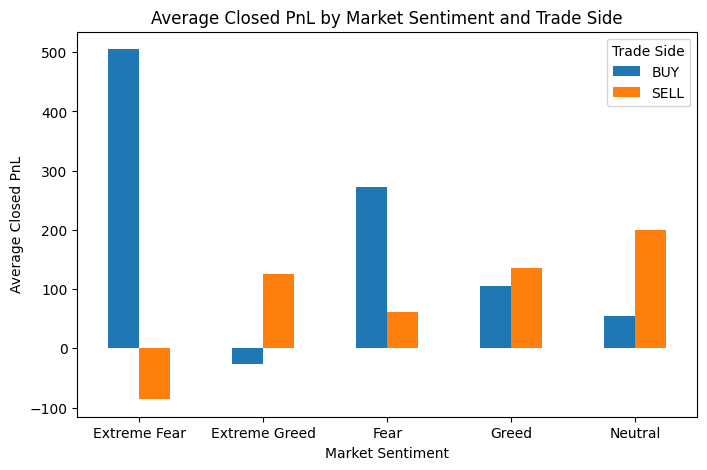

In [45]:
plt.figure(figsize=(8,5))

buy_sell_performance.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Closed PnL by Market Sentiment and Trade Side")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=0)

plt.legend(title="Trade Side")

plt.show()

**Interpretation**

**Key Findings**

- During Extreme Fear, BUY trades generated higher profits than SELL trades.
- During Fear, BUY trades outperformed SELL trades.
- During Greed, SELL trades were slightly more profitable than BUY trades.
- During Neutral, SELL trades generated the highest average profit.
- During Extreme Greed, BUY trades resulted in losses, while SELL trades remained profitable.

**Business Insights**

- BUY strategies performed better during Fear and Extreme Fear market conditions.
- SELL strategies performed better during Neutral, Greed, and Extreme Greed conditions.
- Traders can align their BUY or SELL decisions with market sentiment to improve profitability.

**Long vs Short Performance by Market Sentiment**

Does trading direction (Long or Short) perform differently under various market sentiment conditions?

This analysis compares the average Closed Profit/Loss for Long and Short trades across different market sentiments to identify the most profitable trading direction.

In [52]:
fee_sentiment = merged_df.groupby('classification')['Fee'].mean().sort_values(ascending=False)

display(fee_sentiment)

,Fee
classification,
Greed,4.917674
Fear,4.738100
Neutral,3.457961
Extreme Greed,1.535204
Extreme Fear,1.139536


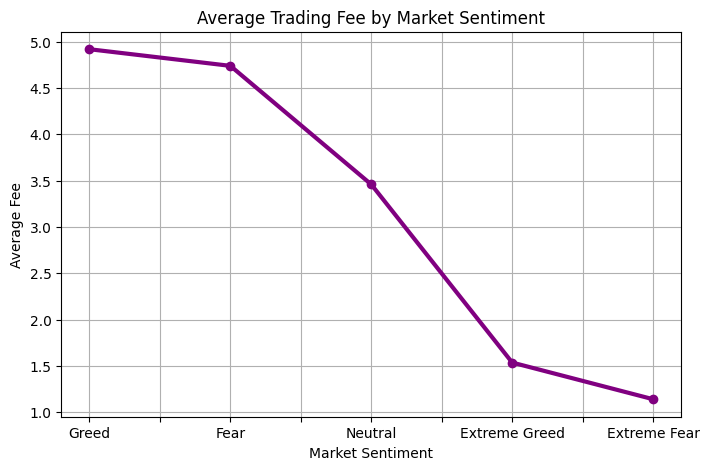

In [53]:
plt.figure(figsize=(8,5))

fee_sentiment.plot(
    kind='line',
    marker='o',
    linewidth=3,
    color='purple'
)

plt.title("Average Trading Fee by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Fee")

plt.grid(True)

plt.show()

**Interpretation**

**Key Findings**

- Greed recorded the highest average trading fee.
- Fear also showed relatively high transaction costs.
- Extreme Fear had the lowest trading fee.
- Trading fees varied across market sentiments.

**Business Insights**

- Higher market activity can lead to increased trading costs.
- Traders should consider transaction fees when planning trades.
- Lower trading fees can improve overall profitability.

**Coin Performance by Market Sentiment**

Which cryptocurrencies generate higher profits under different market sentiment conditions?

This analysis identifies the average Closed Profit/Loss of the top traded cryptocurrencies across various market sentiments to uncover profitable trading opportunities.

In [54]:
top10_coins = merged_df['Coin'].value_counts().head(10).index

coin_sentiment = merged_df[
    merged_df['Coin'].isin(top10_coins)
].pivot_table(
    values='Closed PnL',
    index='Coin',
    columns='classification',
    aggfunc='mean'
)

display(coin_sentiment)

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Coin,,,,,
@107,NaN,344.419237,1.651168,217.499337,101.963397
AIXBT,0.000000,NaN,105.813485,284.838469,0.000000
BERA,NaN,NaN,-4.635416,322.027621,0.000000
BTC,-198.234167,NaN,60.587468,41.962476,82.197933
EIGEN,NaN,NaN,NaN,56.441558,0.000000
ETH,1266.659252,-54.325861,354.257638,-85.880137,258.523679
HYPE,535.411023,0.000000,208.721332,70.052480,52.225981
LAYER,NaN,NaN,88.516779,0.000000,194.835986
SOL,7850.250000,63.999085,839.205625,421.122920,138.359562


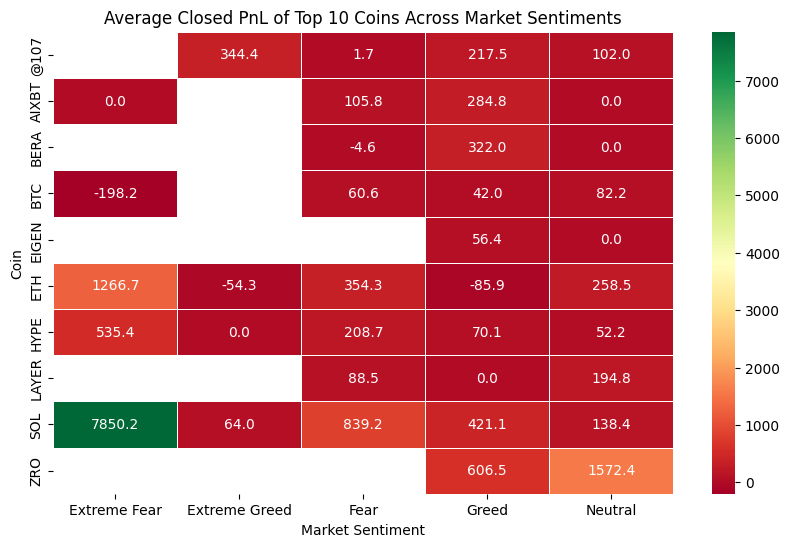

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    coin_sentiment,
    annot=True,
    cmap="RdYlGn",
    fmt=".1f",
    linewidths=0.5
)

plt.title("Average Closed PnL of Top 10 Coins Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Coin")

plt.show()

**Key Findings**

- SOL generated the highest average profit during Extreme Fear (7850.25).
- ETH performed strongly during Extreme Fear and Fear markets.
- ZRO achieved the highest profit under Neutral market conditions.
- BTC showed comparatively lower profitability across most sentiment categories.

**Business Insights**

- Different cryptocurrencies perform better under different market sentiments.
- Market sentiment can help traders choose the most suitable cryptocurrency.
- Combining coin selection with market sentiment may improve trading profitability.

**Business Recommendations**

Based on the analysis, the following trading strategies can help improve trading performance under different market sentiment conditions:

- Prioritize trading during Neutral and Fear market conditions, as they showed the highest profitability and win rates.
- Exercise caution during Extreme Greed, as it recorded the lowest win rate and weakest profit factor.
- Select BUY or SELL strategies based on the prevailing market sentiment, since trading performance varies across sentiment categories.
- Monitor transaction fees, as higher trading fees can reduce overall profitability.
- Consider coin-specific performance before placing trades, as different cryptocurrencies perform differently under different market sentiments.
- Use market sentiment together with proper risk management instead of relying on sentiment alone for trading decisions.

**Conclusion**

This analysis demonstrates that market sentiment has a significant influence on trader performance. By combining sentiment indicators with trading direction, coin selection, transaction costs, and risk management, traders can make more informed decisions and improve overall profitability. These insights can support the development of smarter and more effective trading strategies.